# Experiment 8 — Attention blocking (attention knockout)

Reproduction guidebook §11.

> **Questions.** (1) Can just-in-time computation at CC be excluded, by severing CC's
> attention to question and answer tokens? (2) How does confidence flow from PANL to CC?
> (3) How does confidence reach PANL in the first place?
> **Key result.** answer tokens → PANL (L22–28) → CC (L30–36). JIT ruled out.

**Method (§11.1).** For a source position `s` and target position `t`, the attention weight
α<sub>t←s</sub> is set to zero across **all heads** within a layer window, by adding −∞ to the
pre-softmax attention scores at the (t, s) entries. This requires
`attn_implementation="eager"` so the attention probabilities are materialised.

**The layer-window convention (§11.2) is different from every other experiment.** Blocking is
applied across a window of **12 consecutive layers centred at each x-axis position** — a point
plotted at "layer 30" means layers 24–35 were blocked. Blocking single layers is insufficient
because the pathway is redundant across nearby layers.

**Which prompt (§11.3).** The **minimal numeric (0–9) prompt** is the primary analysis: the
full categorical prompt has more than a hundred intermediate template tokens between PANL and
CC, which provide redundant multi-hop routing that *masks* the direct CC→PANL edge.

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vconf").is_dir())
sys.path.insert(0, str(ROOT))

from vconf import notebook as nb

from vconf import attention
from vconf import exp8_attention_blocking as E8
from vconf import metrics as M
from vconf import models, plotting
from vconf.results import summarize

cfg = nb.run_config("gemma-minimal")   # minimal numeric prompt, eager attention
print(nb.describe(cfg))
print("\npathways (minimal prompt):", attention.MINIMAL_PATHWAYS)

profile          : reduced
model            : Qwen/Qwen2.5-7B-Instruct (28 layers)
prompt / dataset : minimal_numeric / triviaqa
layer sweep      : (0, 5, 11, 16, 22, 27)
trial counts     : {'steering': 24, 'patching': 24, 'noising': 32, 'swap': 24, 'attention': 24}
activation set   : 300   calibration set: 40
chat template    : False   attention impl: eager
NOTE             : reduced profile — procedures, prompts, positions and
                   metrics follow the manual exactly, but the model and the
                   sample sizes are smaller than the paper's, so the numbers
                   here are not expected to match its reported values.

pathways (minimal prompt): ('CC->Q+A', 'CC->PANL', 'CC->PANL+1', 'PANL->A', 'PANL->last_A')


In [2]:
loaded = nb.open_model(cfg)
trials, rendered = nb.build_trials(loaded, cfg, target_n=cfg.trial_counts["attention"])
print(len(trials), "trials")

example = rendered[0]
print("\nprompt tail:", repr(example.text[-90:]))
for name in ("PANL", "PANL+1", "CC", "first A", "last A"):
    index = example.positions[name]
    print(f"  {name:>8} @ {index:>4}: {loaded.tokenizer.decode([example.input_ids[index]])!r}")
print("\nintermediate tokens between PANL and CC:",
      example.positions["CC"] - example.positions["PANL"] - 1,
      "(the categorical prompt has more than a hundred, §11.3)")

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

24 trials

prompt tail: " behind The Chipmunks?\n**Answer**: David Seville\n**State Confidence(0-9) with NO SPACE**:'"
      PANL @   35: '\n'
    PANL+1 @   36: '**'
        CC @   48: ":'"
   first A @   32: ' David'
    last A @   34: 'ville'

intermediate tokens between PANL and CC: 12 (the categorical prompt has more than a hundred, §11.3)


## Verifying the knockout (§11.1)

The manual asks for an explicit check: for a blocked layer, the post-softmax attention from
`t` to `s` must be numerically zero.

In [3]:
from vconf.models import pad_batch

sample = rendered[:2]
input_ids, attention_mask, _ = pad_batch(sample, loaded.tokenizer.pad_token_id, loaded.device)
edges = [attention.pathway_edges(r, "CC->PANL") for r in sample]
block_mask = attention.build_block_mask(edges, input_ids.shape[1], loaded.device,
                                        loaded.model.dtype)
window = attention.window_layers(cfg.attention_sweep[1], loaded.n_layers, cfg.attention_window)
worst = attention.verify_blocked(loaded.model, input_ids, attention_mask, window, block_mask, edges)
print("blocked window:", window)
print("edges blocked (trial 0):", edges[0])
print("max post-softmax attention on a blocked edge:", worst)
assert worst == 0.0, "attention knockout did not zero the blocked edges"

blocked window: [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
edges blocked (trial 0): [(48, 35)]
max post-softmax attention on a blocked edge: 0.0


## Conditions — minimal numeric prompt (§11.4)

| Pathway blocked | Tests |
|---|---|
| **CC → Q + A** | whether CC computes confidence **just-in-time** from question and answer tokens |
| **CC → PANL** | whether CC **retrieves** cached confidence from PANL |
| CC → PANL+1 | **control** |
| **PANL → A** | how PANL **gathers** confidence from the answer |
| PANL → last_A | the same, narrower |

Metrics: the first-token (here first-**digit**) change rate, and the logit-difference change
over the ten digits 0–9.

In [4]:
frame = E8.run_blocking(loaded, rendered, trials, cfg, pathways=attention.MINIMAL_PATHWAYS)
summary = summarize(frame, by=("condition", "layer"))
summary.pivot(index="layer", columns="condition", values="token_changed_mean").round(3)

condition,CC->PANL,CC->PANL+1,CC->Q+A,PANL->A,PANL->last_A
layer,,,,,
10,0.250,0.083,0.292,0.542,0.500
20,0.542,0.083,0.208,0.208,0.208
22,0.583,0.167,0.208,0.208,0.125
26,0.250,0.042,0.125,0.042,0.083


PosixPath('/scratch/qi/project/results/figures/exp8-blocking-minimal-qwen-minimal_numeric-triviaqa-reduced.png')

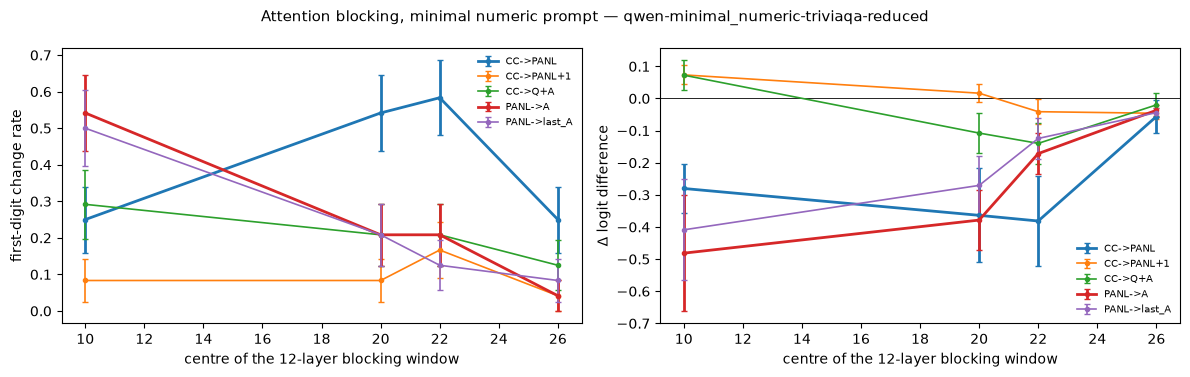

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for condition, group in summary.groupby("condition"):
    group = group.sort_values("layer")
    style = {"linewidth": 2.0} if condition in ("CC->PANL", "PANL->A") else {"linewidth": 1.2}
    axes[0].errorbar(group["layer"], group["token_changed_mean"], yerr=group["token_changed_sem"],
                     marker="o", markersize=3, capsize=2, label=str(condition), **style)
    axes[1].errorbar(group["layer"], group["logit_diff_change_mean"],
                     yerr=group["logit_diff_change_sem"], marker="o", markersize=3, capsize=2,
                     label=str(condition), **style)
axes[0].set_ylabel("first-digit change rate")
axes[1].set_ylabel("Δ logit difference")
axes[1].axhline(0, color="k", lw=0.6)
for ax in axes:
    ax.set_xlabel("centre of the 12-layer blocking window")
    ax.legend(fontsize=7, frameon=False)
fig.suptitle(f"Attention blocking, minimal numeric prompt — {cfg.name}", fontsize=11)
fig.tight_layout()
plotting.save_figure(fig, f"exp8-blocking-minimal-{cfg.name}")

## Peak layers and the layer gap (§11.6, §11.8)

| Pathway | First-token change rate | Logit diff change | Peak layers |
|---|---|---|---|
| **CC → PANL** | ≈ 21% | ≈ −0.80 | **L30–36** |
| CC → Q + A | ≈ 10% — indistinguishable from control | ≈ −0.2 | — |
| CC → PANL+1 (control) | ≈ 10% | ≈ 0 | — |
| **PANL → A** | ≈ 20% | ≈ −0.85 | **L22–28** |
| **PANL → last_A** | ≈ 20% | ≈ −0.75 | **L22–28** |

The PANL→answer effect **precedes** the CC→PANL effect by approximately 6–8 layers.

In [6]:
peaks = E8.pathway_peak_layers(summary)
rows = []
for condition in attention.MINIMAL_PATHWAYS:
    group = summary[summary["condition"] == condition]
    paper = E8.PAPER_TARGETS_MINIMAL[condition]
    rows.append({
        "pathway": condition,
        "peak window centre": peaks.get(condition),
        "paper peak layers": paper.get("peak_layers"),
        "max change rate": round(float(group["token_changed_mean"].max()), 3),
        "paper rate": paper["token_change_rate"],
        "min Δ logit diff": round(float(group["logit_diff_change_mean"].min()), 3),
        "paper Δ logit diff": paper["logit_diff_change"],
    })
pd.DataFrame(rows)

,pathway,peak window centre,paper peak layers,max change rate,paper rate,min Δ logit diff,paper Δ logit diff
0,CC->Q+A,10,None,0.292,0.10,-0.140,-0.20
1,CC->PANL,22,"(30, 36)",0.583,0.21,-0.381,-0.80
2,CC->PANL+1,22,None,0.167,0.10,-0.046,0.00
3,PANL->A,10,"(22, 28)",0.542,0.20,-0.481,-0.85
4,PANL->last_A,10,"(22, 28)",0.500,0.20,-0.409,-0.75


In [7]:
gap = peaks.get("CC->PANL", 0) - peaks.get("PANL->A", 0)
print(f"layer gap between PANL->A and CC->PANL peaks: {gap} (paper: {E8.LAYER_GAP[0]}–{E8.LAYER_GAP[1]})")

for pathway in ("CC->PANL", "CC->Q+A", "PANL->A"):
    layer = peaks.get(pathway, cfg.attention_sweep[0])
    stats = E8.exceeds_control(frame, pathway, "CC->PANL+1", layer=layer)
    print(f"{pathway:>12} vs CC->PANL+1 at L{layer}: "
          f"Δ rate = {stats['mean_difference']:+.3f} ± {stats['sem_difference']:.3f}, "
          f"p = {stats['t_p']:.3g}")

layer gap between PANL->A and CC->PANL peaks: 12 (paper: 6–8)
    CC->PANL vs CC->PANL+1 at L22: Δ rate = +0.417 ± 0.103, p = 0.000493
     CC->Q+A vs CC->PANL+1 at L10: Δ rate = +0.208 ± 0.085, p = 0.0218
     PANL->A vs CC->PANL+1 at L10: Δ rate = +0.458 ± 0.120, p = 0.000885


In [8]:
def rate_at(condition, layer):
    row = summary[(summary["condition"] == condition) & (summary["layer"] == layer)]
    return float(row["token_changed_mean"].iloc[0]) if len(row) else float("nan")

def peak_rate(condition):
    group = summary[summary["condition"] == condition]
    return float(group["token_changed_mean"].max()) if len(group) else float("nan")

# The paper reads these pathways off one figure, window by window: the JIT test is
# whether CC->Q+A matches the control *where the CC->PANL retrieval effect lives*.
retrieval_layer = peaks["CC->PANL"]
print(f"at the CC->PANL peak window (centre L{retrieval_layer}):")
for condition in ("CC->PANL", "CC->Q+A", "CC->PANL+1"):
    print(f"  {condition:>12}: change rate {rate_at(condition, retrieval_layer):.3f}")
print("\nmax across all windows (noisier at small n):")
for condition in ("CC->PANL", "CC->Q+A", "CC->PANL+1"):
    print(f"  {condition:>12}: {peak_rate(condition):.3f}")

control_here = rate_at("CC->PANL+1", retrieval_layer)
checks = {
    "Q10 blocking CC->Q+A stays near the control where retrieval happens (JIT ruled out)":
        rate_at("CC->Q+A", retrieval_layer) - control_here
        < rate_at("CC->PANL", retrieval_layer) - control_here,
    "Q11 blocking CC->PANL substantially disrupts confidence":
        peak_rate("CC->PANL") > peak_rate("CC->PANL+1"),
    "Q12 blocking PANL->answer disrupts at earlier layers than CC->PANL":
        peaks.get("PANL->A", 10**6) <= peaks.get("CC->PANL", 0),
    "PANL->last_A behaves like PANL->A":
        abs(peak_rate("PANL->last_A") - peak_rate("PANL->A")) < 0.25,
}
print()
for name, ok in checks.items():
    print(f"{'PASS' if ok else 'FAIL'}  {name}")

at the CC->PANL peak window (centre L22):
      CC->PANL: change rate 0.583
       CC->Q+A: change rate 0.208
    CC->PANL+1: change rate 0.167

max across all windows (noisier at small n):
      CC->PANL: 0.583
       CC->Q+A: 0.292
    CC->PANL+1: 0.167

PASS  Q10 blocking CC->Q+A stays near the control where retrieval happens (JIT ruled out)
PASS  Q11 blocking CC->PANL substantially disrupts confidence
PASS  Q12 blocking PANL->answer disrupts at earlier layers than CC->PANL
PASS  PANL->last_A behaves like PANL->A


Note the two ways of reading the CC→Q+A condition. Window by window, at the layers where
the CC→PANL retrieval effect lives, blocking CC's access to the question and answer stays near
the PANL+1 control — the paper's just-in-time test. Taking the maximum over *all* windows
instead can put CC→Q+A above the control at an early window when the trial count is small,
where a couple of flipped digits move the rate several points; the paper's 500-trial curves
are flat there. Both numbers are printed so the difference is visible rather than hidden by
the choice of summary.

## The complementary run — full categorical prompt (§11.5, §11.7)

Notation: `NL` = PANL, `NL+1` = PANL+1, `A` = all answer tokens, `last_A` = the last answer
token, `Q` = all question tokens, `ALL` = all downstream tokens. **`_keepNL` means the pathway
is blocked *except* that PANL is still allowed to attend to the answer tokens** — the crucial
dissociation.

The paper expects CC→NL to be **null here** (masked by redundant routing) while `ALL→NL` still
shows PANL is a cache, and the `_keepNL` conditions cut the disruption roughly in half.

In [9]:
cat_cfg = nb.run_config("gemma-categorical", attn_implementation="eager")
cat_loaded = nb.open_model(cat_cfg)
cat_trials, cat_rendered = nb.build_trials(cat_loaded, cat_cfg)
cat_trials = cat_trials[:cat_cfg.trial_counts["attention"]]
cat_rendered = cat_rendered[:cat_cfg.trial_counts["attention"]]
print(len(cat_trials), "trials |",
      cat_rendered[0].positions["CC"] - cat_rendered[0].positions["PANL"] - 1,
      "intermediate tokens between PANL and CC")

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

24 trials | 238 intermediate tokens between PANL and CC


In [10]:
cat_frame = E8.run_blocking(cat_loaded, cat_rendered, cat_trials, cat_cfg,
                            pathways=attention.CATEGORICAL_PATHWAYS)
cat_summary = summarize(cat_frame, by=("condition", "layer"))
best = cat_summary.groupby("condition")["token_changed_mean"].max().round(3)
paper = {k: v["token_change_rate"] for k, v in E8.PAPER_TARGETS_CATEGORICAL.items()}
pd.DataFrame({"reproduction (max change rate)": best, "paper": pd.Series(paper)}).loc[
    list(attention.CATEGORICAL_PATHWAYS)
]

,reproduction (max change rate),paper
CC->NL+1,0.083,0.100
CC->NL,0.083,0.090
CC->A,0.083,0.120
CC->Q,0.083,0.110
CC->Q+A,0.125,0.120
ALL->NL,0.167,0.190
ALL->last_A,0.458,0.510
ALL->NL+last_A,0.375,0.480
ALL->last_A_keepNL,0.250,0.220
ALL->A,0.417,0.685


In [11]:
keep = E8.keep_nl_effect(cat_summary)
keep.sort_values(["blocked", "layer"])

,layer,blocked,blocked_value,keepNL_value,reduction
4,10,ALL->A,0.416667,0.208333,0.208333
5,20,ALL->A,0.333333,0.333333,0.000000
6,22,ALL->A,0.333333,0.375000,-0.041667
7,26,ALL->A,0.000000,0.041667,-0.041667
0,10,ALL->last_A,0.458333,0.083333,0.375000
1,20,ALL->last_A,0.375000,0.166667,0.208333
2,22,ALL->last_A,0.291667,0.250000,0.041667
3,26,ALL->last_A,0.000000,0.000000,0.000000


PosixPath('/scratch/qi/project/results/figures/exp8-blocking-categorical-qwen-categorical-triviaqa-reduced.png')

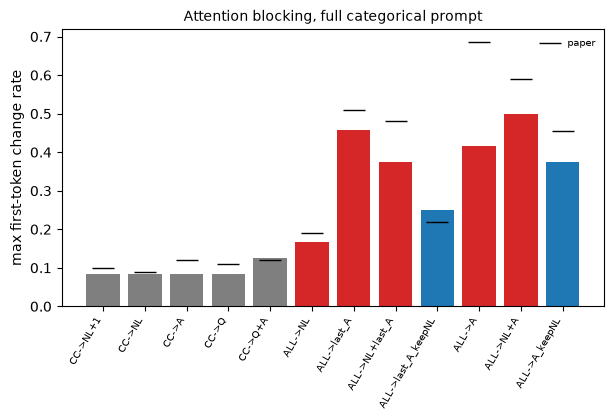

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.6))
order = list(attention.CATEGORICAL_PATHWAYS)
values = [float(cat_summary[cat_summary["condition"] == c]["token_changed_mean"].max())
          for c in order]
colors = ["#1f77b4" if "keepNL" in c else ("#7f7f7f" if c.startswith("CC") else "#d62728")
          for c in order]
ax.bar(np.arange(len(order)), values, color=colors)
ax.plot(np.arange(len(order)), [paper[c] for c in order], "k_", markersize=16, label="paper")
ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels(order, rotation=60, ha="right", fontsize=7)
ax.set_ylabel("max first-token change rate")
ax.set_title("Attention blocking, full categorical prompt", fontsize=10)
ax.legend(fontsize=7, frameon=False)
plotting.save_figure(fig, f"exp8-blocking-categorical-{cat_cfg.name}")

In [13]:
def cat_rate(condition):
    group = cat_summary[cat_summary["condition"] == condition]
    return float(group["token_changed_mean"].max()) if len(group) else float("nan")

checks = {
    "ALL->NL disrupts beyond the CC->NL+1 control": cat_rate("ALL->NL") > cat_rate("CC->NL+1"),
    "blocking everything from the answer is highly disruptive":
        cat_rate("ALL->A") > cat_rate("ALL->NL"),
    "preserving only PANL->answer cuts that disruption (ALL->A_keepNL)":
        cat_rate("ALL->A_keepNL") < cat_rate("ALL->A"),
    "preserving only PANL->answer cuts it for last_A too":
        cat_rate("ALL->last_A_keepNL") < cat_rate("ALL->last_A"),
    "CC->Q+A stays near the control here as well":
        cat_rate("CC->Q+A") <= cat_rate("CC->NL+1") * 2,
}
for name, ok in checks.items():
    print(f"{'PASS' if ok else 'FAIL'}  {name}")
print("\nsequential flow established by the paper:", E8.INFORMATION_FLOW)

PASS  ALL->NL disrupts beyond the CC->NL+1 control
PASS  blocking everything from the answer is highly disruptive
PASS  preserving only PANL->answer cuts that disruption (ALL->A_keepNL)
PASS  preserving only PANL->answer cuts it for last_A too
PASS  CC->Q+A stays near the control here as well

sequential flow established by the paper: answer tokens → PANL (L22–28) → CC (L30–36) → unembedding (L61)


## Interpretation (§11.8) and the caveat you must carry (§11.9)

1. **CC does not compute confidence from scratch.** Blocking CC's attention to question and
   answer tokens produces effects indistinguishable from the PANL+1 control, in *both*
   prompts. If CC were integrating question/answer information de novo, severing that access
   would be catastrophic. It is not.
2. **CC retrieves confidence from PANL.** In the minimal prompt, blocking CC→PANL produces
   substantial disruption. The categorical prompt's null on that edge is explained by
   redundant routing through the template tokens, and `ALL→NL` confirms PANL is a cache there
   too.
3. **PANL reads confidence from answer tokens**, at *earlier* layers. The `_keepNL` conditions
   are the cleanest demonstration: blocking everything downstream from attending to the answer
   is highly disruptive, but **preserving only the PANL→answer pathway cuts that disruption
   substantially**.

**Caveat.** Following Geva et al. (2023), this method does not account for information that
may have already passed between positions at earlier layers, before the blocking window.
**Null results must therefore be interpreted cautiously** — exactly what happened with CC→PANL
in the categorical prompt — while positive results are evidence that the blocked pathway
carries task-relevant information at the targeted layers.